In [1]:
import os
try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()
from src.figures import save_figure

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use(os.path.join(BASE,"..", "configs", "visualisations.mplstyle"))

directory = "data"
file_name = "1900_2021_DISASTERS.csv"
file_path = os.path.join(BASE,"..", directory, file_name)

df = pd.read_csv(file_path)

figure_path = os.path.join(BASE, '01_figures')
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

# VL 01: Fundamentals Statistic & Probability Theory

In [2]:
df = df.convert_dtypes()
df['Total Damages (US$)'] = df['Total Damages (\'000 US$)'] * 1000

df['date'] = pd.to_datetime(
    dict(
        year=df['Start Year'],
        month=df['Start Month'].fillna(1).astype(int),
        day=df['Start Day'].fillna(1).astype(int)
    ),
    errors='coerce'
)

df['Disaster Type'] = df['Disaster Type'].astype('category')
df.dtypes

Year                                   Int64
Seq                                    Int64
Glide                         string[python]
Disaster Group                string[python]
Disaster Subgroup             string[python]
Disaster Type                       category
Disaster Subtype              string[python]
Disaster Subsubtype           string[python]
Event Name                    string[python]
Country                       string[python]
ISO                           string[python]
Region                        string[python]
Continent                     string[python]
Location                      string[python]
Origin                        string[python]
Associated Dis                string[python]
Associated Dis2               string[python]
OFDA Response                 string[python]
Appeal                        string[python]
Declaration                   string[python]
Aid Contribution                       Int64
Dis Mag Value                          Int64
Dis Mag Sc

**Fig. 1.1** Damage distribution

Saved Fig. 1.1 -> 01_figures/1.1_damage_distribution/1.1_damage_distribution.pdf


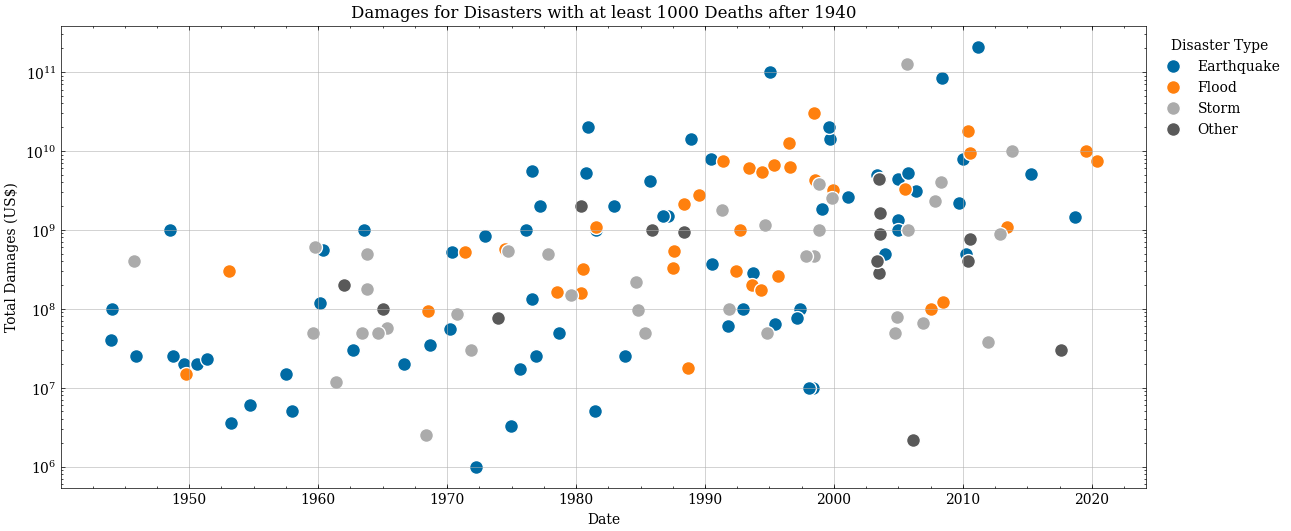

In [3]:
df_subset = df[df['Total Deaths'] >= 1000]
df_subset = df_subset[df_subset["Year"] > 1940]

df_subset['Disaster visual'] = df_subset['Disaster Type'].apply(
    lambda x: x if x in ['Earthquake', 'Flood', 'Storm'] else 'Other'
)

defined_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, disasters in enumerate(['Earthquake', 'Flood', 'Storm', 'Other']):
    plt.scatter(data=df_subset[df_subset['Disaster visual'] == disasters], x='date', y='Total Damages (US$)', s=100, c=defined_colors[i], label=disasters, alpha=1, edgecolors='w', linewidth=1)
plt.title('Damages for Disasters with at least 1000 Deaths after 1940')
plt.xlabel('Date')
plt.ylabel('Total Damages (US$)')
plt.yscale('log')  
plt.legend(title='Disaster Type',bbox_to_anchor=(1.0, 1), loc='upper left')
save_figure(1, 1, 'damage_distribution')
plt.show()

In [4]:
df['Total Deaths'].fillna(0, inplace=True)
df['Total Deaths'] = df['Total Deaths'].astype(int)
df['Total Damages (US$)'] = df['Total Damages (US$)'].astype(float)
df.dtypes

Year                                   Int64
Seq                                    Int64
Glide                         string[python]
Disaster Group                string[python]
Disaster Subgroup             string[python]
Disaster Type                       category
Disaster Subtype              string[python]
Disaster Subsubtype           string[python]
Event Name                    string[python]
Country                       string[python]
ISO                           string[python]
Region                        string[python]
Continent                     string[python]
Location                      string[python]
Origin                        string[python]
Associated Dis                string[python]
Associated Dis2               string[python]
OFDA Response                 string[python]
Appeal                        string[python]
Declaration                   string[python]
Aid Contribution                       Int64
Dis Mag Value                          Int64
Dis Mag Sc

In [5]:
pd.merge(df['Disaster Type'].value_counts(), (df['Disaster Type'].value_counts()/len(df)).round(2), left_index=True, right_index=True, suffixes=('', '_proportion'))

,count,count_proportion
Disaster Type,,
Flood,5551,0.34
Storm,4496,0.28
Earthquake,1544,0.10
Epidemic,1501,0.09
Landslide,776,0.05
Drought,770,0.05
Extreme temperature,603,0.04
Wildfire,471,0.03
Volcanic activity,265,0.02


**Fig. 1.2** Empirical CDF of damages

Saved Fig. 1.2 -> 01_figures/1.2_ecdf/1.2_ecdf.pdf


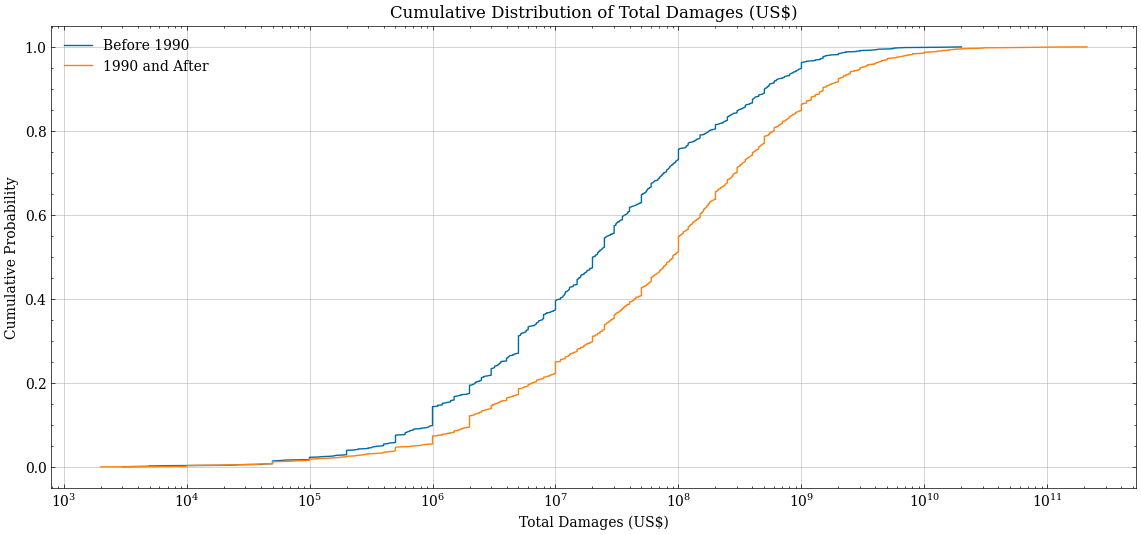

In [6]:
before_1990 = df[df['Year'] < 1990]['Total Damages (US$)'].dropna().values
after_1990 = df[df['Year'] >= 1990]['Total Damages (US$)'].dropna().values

sorted_before = np.sort(before_1990)
cum_prob_before = np.arange(1, len(sorted_before)+1) / len(sorted_before)

sorted_after = np.sort(after_1990)
cum_prob_after = np.arange(1, len(sorted_after)+1) / len(sorted_after)

plt.plot(sorted_before, cum_prob_before, label='Before 1990')
plt.plot(sorted_after, cum_prob_after, label='1990 and After')
plt.xlabel('Total Damages (US$)')
plt.xscale('log')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution of Total Damages (US$)')
plt.legend()
save_figure(1, 2, 'ecdf')
plt.show()

**Fig. 1.3** Histogram binning

Saved Fig. 1.3 -> 01_figures/1.3_binning/1.3_binning_bins5.pdf


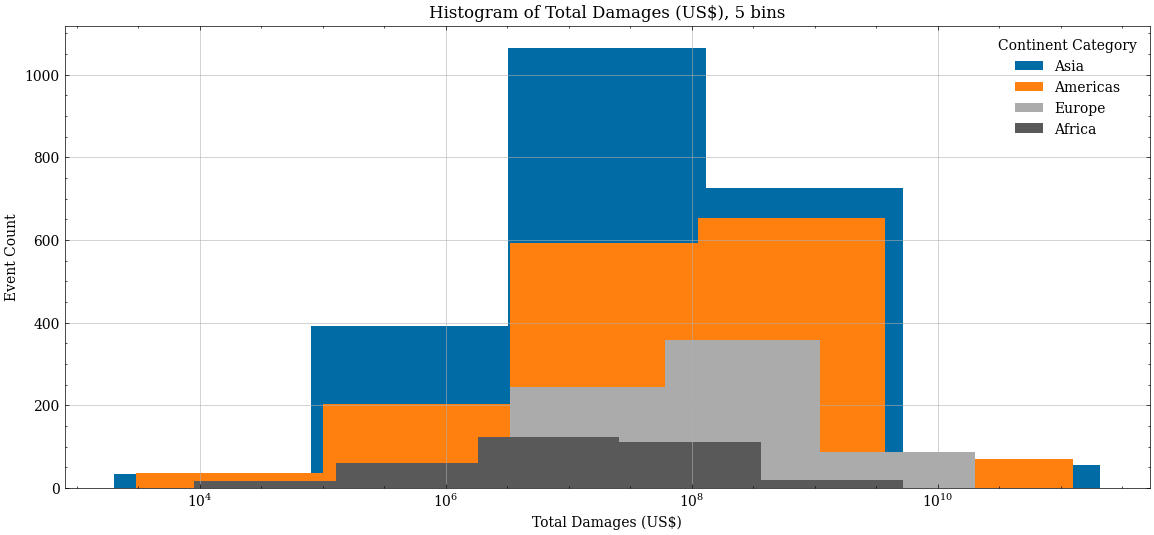

In [7]:
def _plot_histogram(df, diff_column, hist_column, number_bins=100):
    df["Continent Category"] = df["Continent"].apply(
        lambda x: x if x in ["Africa", "Asia", "Americas", "Europe"] else "Other"
    )

    df_plot = df[
        df[hist_column].notna() & np.isfinite(df[hist_column]) & df[diff_column].notna()
    ]
    df_plot = df_plot[df_plot[hist_column] > 0]

    for category in [
        "Asia",
        "Americas",
        "Europe",
        "Africa",
    ]:
        subset = df_plot[df_plot[diff_column] == category]
        log_values = np.log10(subset[hist_column])
        plt.hist(log_values, label=category, bins=number_bins, fill=True, alpha=1)

    plt.title(f"Histogram of {hist_column}, {number_bins} bins")
    plt.xlabel(hist_column)
    plt.xticks(ticks=np.log10([1e4, 1e6, 1e8, 1e10]), labels=['$10^4$', '$10^6$', '$10^8$', '$10^{10}$'])
    plt.ylabel("Event Count")
    plt.legend(title=diff_column)
    save_figure(1, 3, 'binning', variant=f'bins{number_bins}')
    plt.show()

diff_column = "Continent Category"
hist_column = "Total Damages (US$)"

_plot_histogram(df, diff_column, hist_column, number_bins=5)

Saved Fig. 1.3 -> 01_figures/1.3_binning/1.3_binning_bins30.pdf


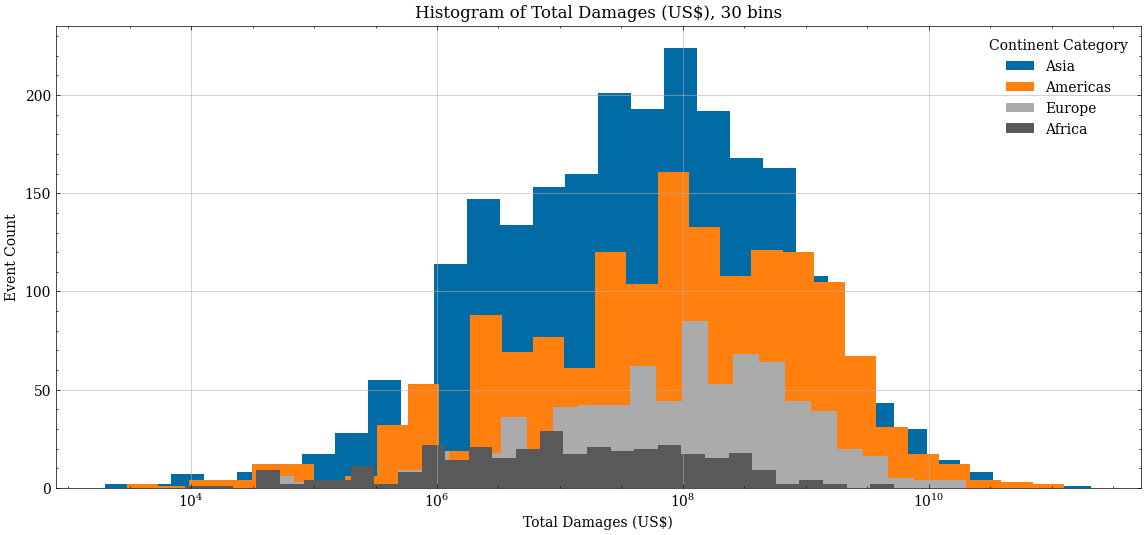

In [8]:
_plot_histogram(df, diff_column, hist_column, number_bins=30)

Saved Fig. 1.3 -> 01_figures/1.3_binning/1.3_binning_bins100.pdf


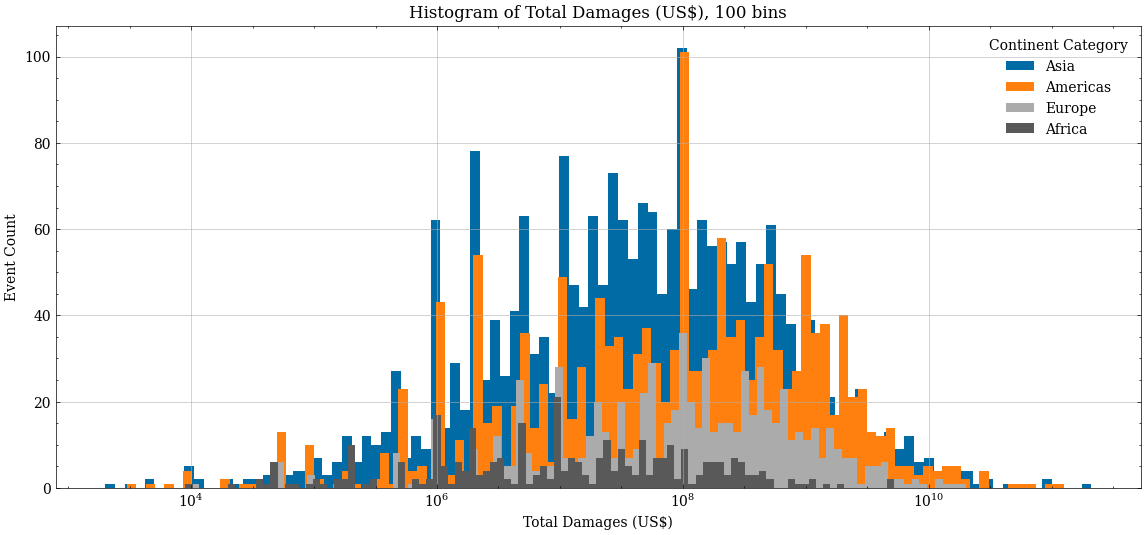

In [9]:
_plot_histogram(df, diff_column, hist_column, number_bins=100)


**Fig. 1.4** Summary statistics on the histogram

/var/folders/ct/qpfxjbdn1xx4fvb2v099sg_00000gn/T/ipykernel_29202/2385938903.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_plain.pdf


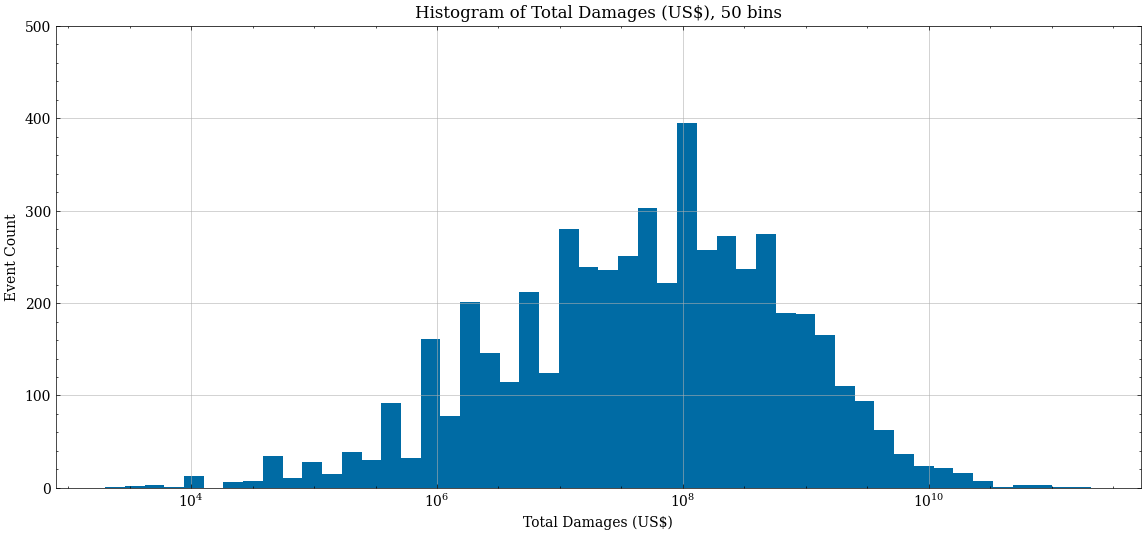

In [10]:
def _plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=False,
    mean=False,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title=None,
):
    defined_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    df_plot = df[df[hist_column].notna() & np.isfinite(df[hist_column])]
    df_plot = df_plot[df_plot[hist_column] > 0]
    log_values = np.log10(df[hist_column])

    plt.hist(log_values, bins=number_bins, fill=True, alpha=1)
    plt.title(f"Histogram of {hist_column}, {number_bins} bins")
    plt.xlabel(hist_column)
    plt.xticks(
        ticks=np.log10([1e4, 1e6, 1e8, 1e10]),
        labels=["$10^4$", "$10^6$", "$10^8$", "$10^{10}$"],
    )

    if five_percentile:
        five_percentile_value = log_values.quantile(0.05)
        plt.axvline(
            five_percentile_value,
            color=defined_colors[3],
            linestyle="dashed",
            linewidth=line_width,
            label="5th Percentile",
        )
    if mean:
        mean_value = log_values.mean()
        plt.axvline(
            mean_value,
            color=defined_colors[0],
            linestyle="dashed",
            linewidth=line_width,
            label="Mean",
        )
    if median:
        median_value = log_values.median()
        plt.axvline(
            median_value,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="Median",
        )
    if mode:
        mode_value = log_values.mode()[0]
        plt.axvline(
            mode_value,
            color=defined_colors[2],
            linestyle="dashed",
            linewidth=line_width,
            label="Mode",
        )
    if ninety_five_percentile:
        ninety_five_percentile_value = log_values.quantile(0.95)
        plt.axvline(
            ninety_five_percentile_value,
            color=defined_colors[4],
            linestyle="dashed",
            linewidth=line_width,
            label="95th Percentile",
        )

    if std:
        mean_value = log_values.mean()
        std = log_values.std()
        plt.axvline(
            mean_value + std,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="Mean +/- Std.",
        )
        plt.axvline(
            mean_value - std,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="",
        )
    if iqr:
        interquartile_range = log_values.quantile(0.75) - log_values.quantile(0.25)
        plt.axvline(
            log_values.quantile(0.25),
            color=defined_colors[3],
            linestyle="dashed",
            linewidth=line_width,
            label="1st/3rd Quartile",
        )
        plt.axvline(
            log_values.quantile(0.75),
            color=defined_colors[3],
            linestyle="dashed",
            linewidth=line_width,
            label="",
        )
    if range:
        range_values = (log_values.min(), log_values.max())
        plt.axvline(
            range_values[0],
            color=defined_colors[2],
            linestyle="dashed",
            linewidth=line_width,
            label="Min/Max",
        )
        plt.axvline(
            range_values[1],
            color=defined_colors[2],
            linestyle="dashed",
            linewidth=line_width,
            label="",
        )

    plt.legend()
    plt.ylim(0, 500)
    plt.ylabel("Event Count")
    save_figure(1, 4, 'histogram_measures', variant=(title or 'plain'))
    
    plt.show()


_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=False,
    mean=False,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
)

Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_mean.pdf


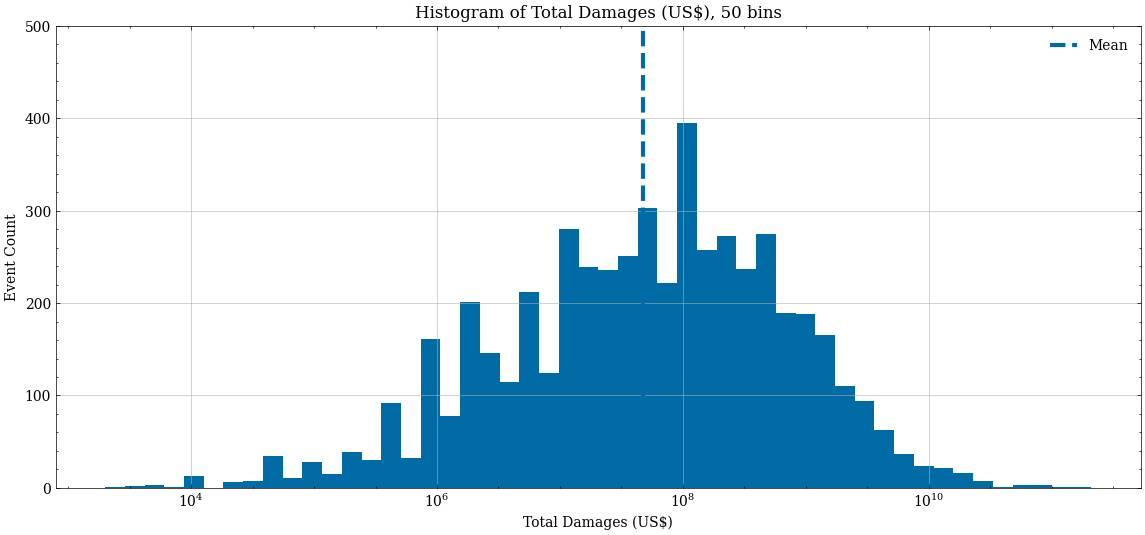

In [11]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=False,
    mean=True,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean"
)

Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_mean_median.pdf


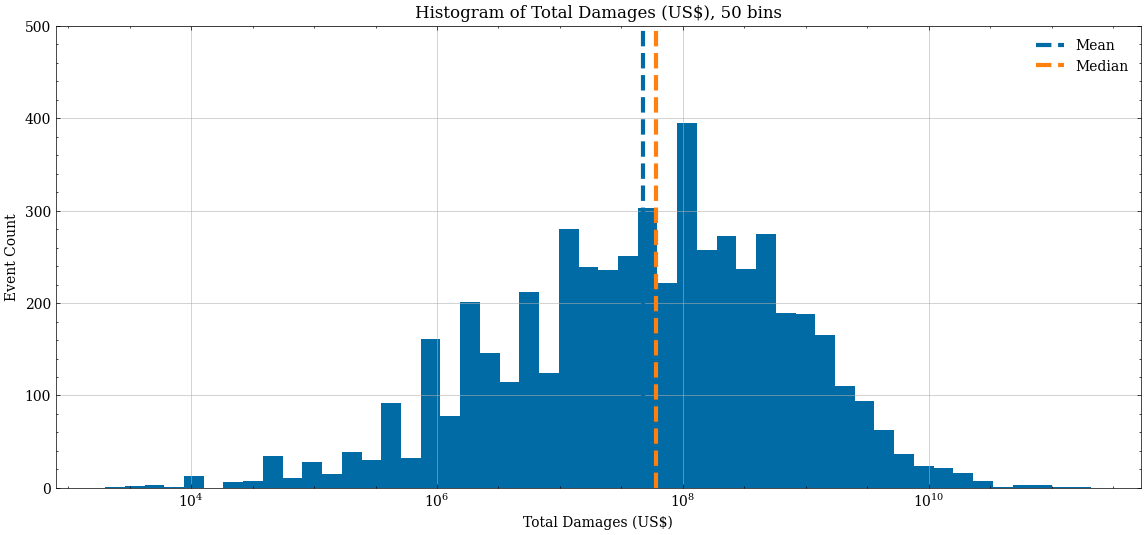

In [12]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=True,
    mean=True,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean_median"
)

Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_mean_median_mode.pdf


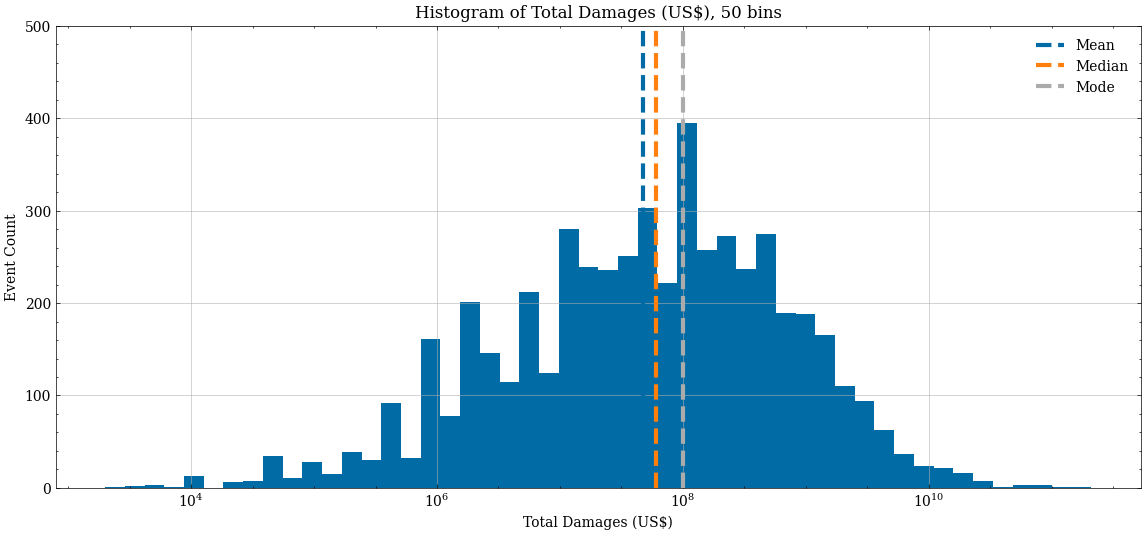

In [13]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=True,
    mean=True,
    mode=True,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean_median_mode"
)

Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_mean_median_mode_percentiles.pdf


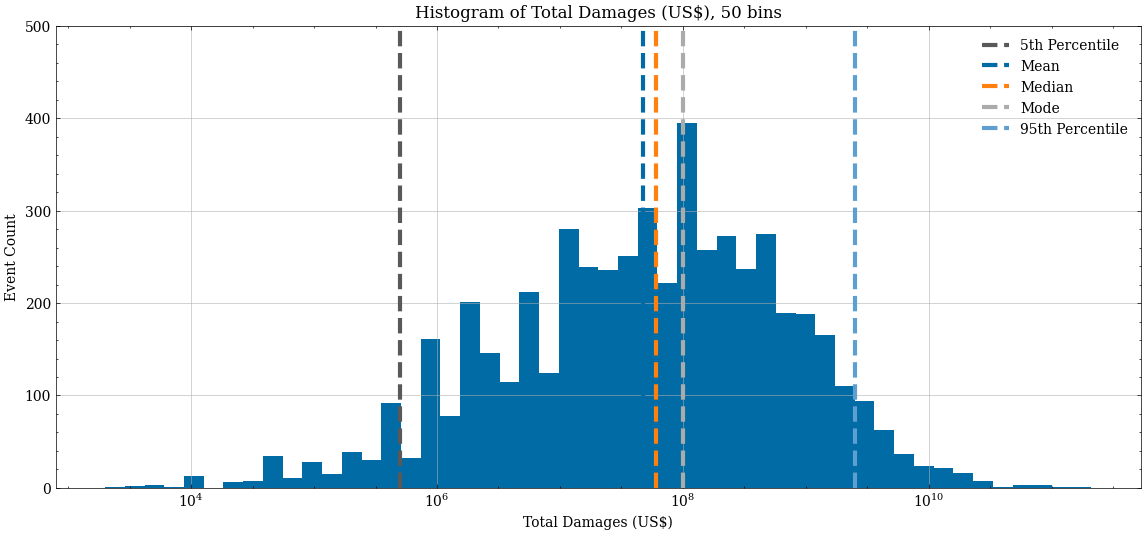

In [14]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=True,
    median=True,
    mean=True,
    mode=True,
    ninety_five_percentile=True,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean_median_mode_percentiles"
)

Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_mean_std.pdf


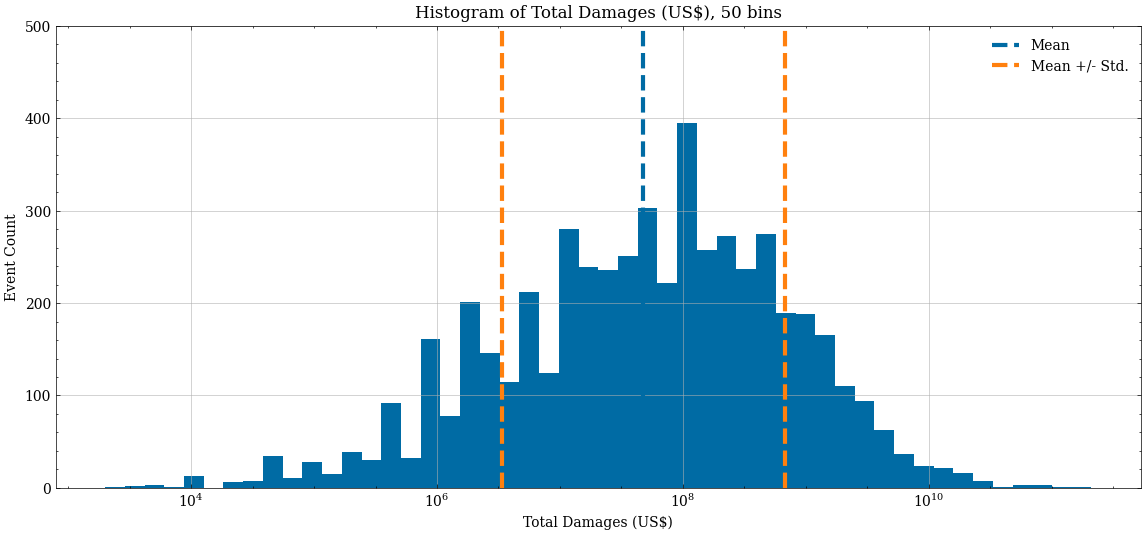

In [15]:
_plot_histogram(
df,
hist_column="Total Damages (US$)",
number_bins=50,
five_percentile=False,
median=False,
mean=True,
mode=False,
ninety_five_percentile=False,
std=True,
iqr=False,
range=False,
line_width=3,
title="mean_std"
)    


Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_mean_std_range.pdf


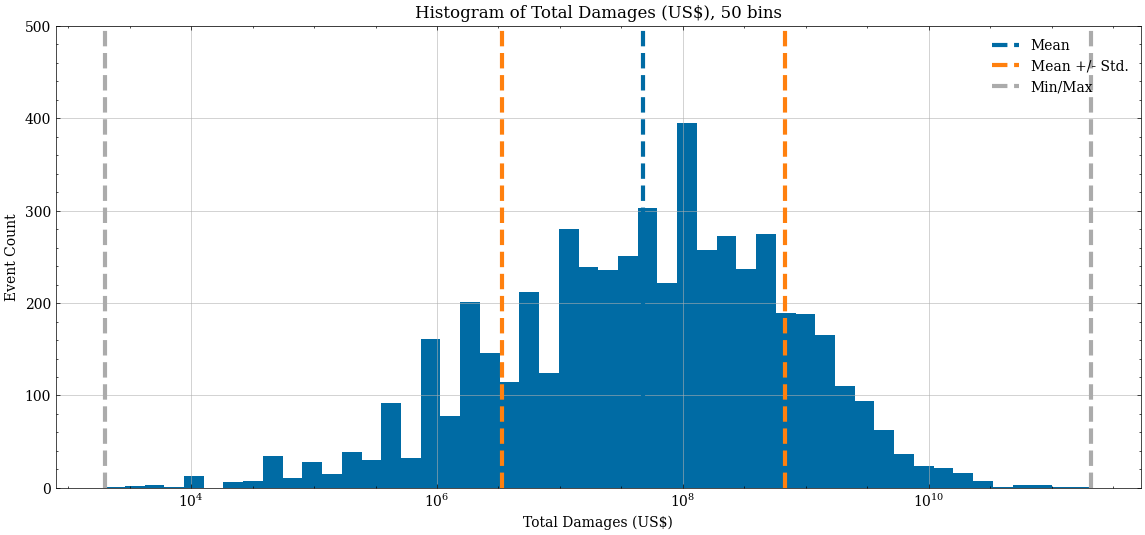

In [16]:
_plot_histogram(
df,
hist_column="Total Damages (US$)",
number_bins=50,
five_percentile=False,
median=False,
mean=True,
mode=False,
ninety_five_percentile=False,
std=True,
iqr=False,
range=True,
line_width=3,
title="mean_std_range"
)    


Saved Fig. 1.4 -> 01_figures/1.4_histogram_measures/1.4_histogram_measures_mean_std_iqr_range.pdf


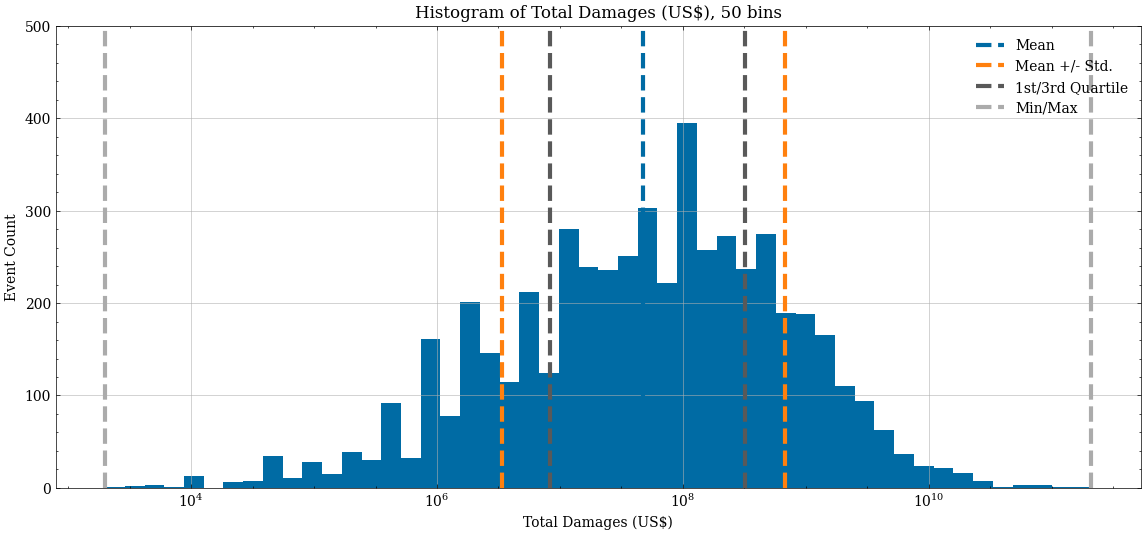

In [17]:
_plot_histogram(
df,
hist_column="Total Damages (US$)",
number_bins=50,
five_percentile=False,
median=False,
mean=True,
mode=False,
ninety_five_percentile=False,
std=True,
iqr=True,
range=True,
line_width=3,
title="mean_std_iqr_range"
)    


**Fig. 1.5** Boxplot and dispersion

Saved Fig. 1.5 -> 01_figures/1.5_boxplot_dispersion/1.5_boxplot_dispersion_bins50.pdf


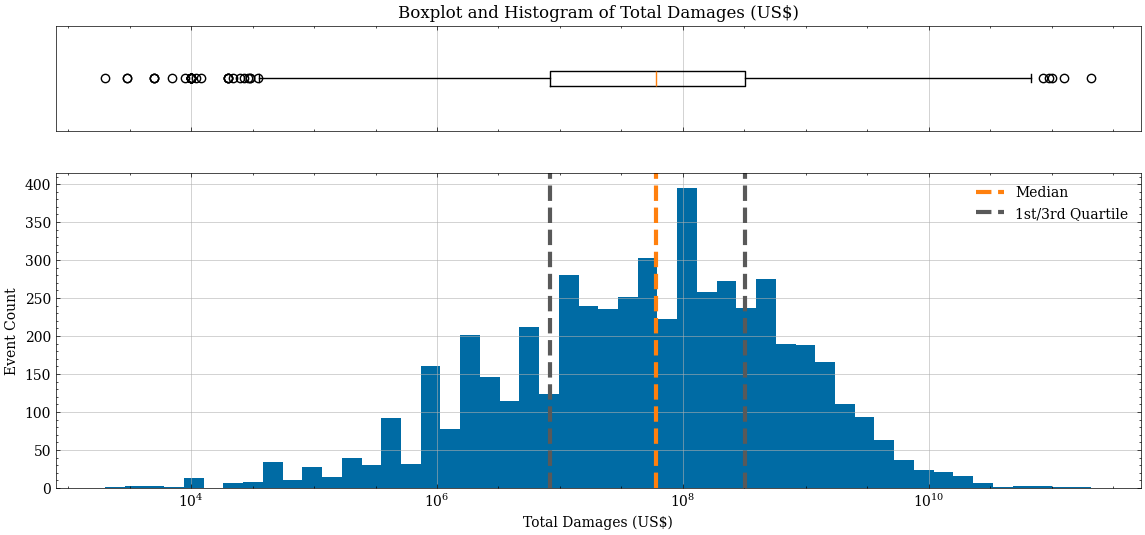

In [18]:
def _plot_boxplot(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    line_width=3,
):
    df_plot = df[df[hist_column].notna() & np.isfinite(df[hist_column])]
    df_plot = df_plot[df_plot[hist_column] > 0]
    log_values = np.log10(df_plot[hist_column])

    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, ncols=1, sharex=True, gridspec_kw={"height_ratios": [1, 3]}, 
    )

    median_value = log_values.median()
    ax_hist.axvline(
            median_value,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="Median",
        )
    ax_hist.axvline(
        log_values.quantile(0.25),
        color=defined_colors[3],
        linestyle="dashed",
        linewidth=line_width,
        label="1st/3rd Quartile",
    )
    ax_hist.axvline(
        log_values.quantile(0.75),
        color=defined_colors[3],
        linestyle="dashed",
        linewidth=line_width,
        label="",
        )
        
    ax_box.boxplot(log_values, vert=False)
    ax_box.set(yticks=[], ylabel="")
    ax_box.set_title(f"Boxplot and Histogram of {hist_column}")

    ax_hist.hist(log_values, bins=number_bins, fill=True, alpha=1)
    ax_hist.set_xlabel(hist_column)
    ax_hist.set_xticks(np.log10([1e4, 1e6, 1e8, 1e10]))
    ax_hist.set_xticklabels(['$10^4$', '$10^6$', '$10^8$', '$10^{10}$'])
    ax_hist.set_ylabel("Event Count")
    plt.legend()
    save_figure(1, 5, 'boxplot_dispersion', variant=f'bins{number_bins}')
    plt.show()


_plot_boxplot(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
)

In [19]:
df["Continent Category"] = df["Continent"].apply(
        lambda x: x if x in ["Africa", "Asia", "Americas", "Europe"] else "Other"
    )
df["Disaster Category"] = df["Disaster Type"].apply(
    lambda x: x if x in ['Earthquake', 'Flood', 'Storm'] else 'Other'
)

df_comparison = df.groupby(["Continent Category", "Disaster Category"]).size().unstack(fill_value=0)
number_events = df_comparison.sum().sum()   

df_comparison['Total'] = df_comparison.sum(axis=1)
df_comparison.loc['Total'] = df_comparison.sum()

cols = ['Earthquake', 'Flood', 'Storm', 'Other', 'Total']
df_comparison = df_comparison[cols]

df_comparison_relative = (df_comparison / number_events).round(2)
df_comparison_combined = df_comparison.astype(str) + " (" + df_comparison_relative.astype(str) + ")"

df_comparison_combined

Disaster Category,Earthquake,Flood,Storm,Other,Total
Continent Category,,,,,
Africa,74 (0.0),1147 (0.07),290 (0.02),1435 (0.09),2946 (0.18)
Americas,314 (0.02),1275 (0.08),1442 (0.09),940 (0.06),3971 (0.25)
Asia,903 (0.06),2303 (0.14),1884 (0.12),1400 (0.09),6490 (0.4)
Europe,197 (0.01),668 (0.04),542 (0.03),590 (0.04),1997 (0.12)
Other,56 (0.0),158 (0.01),338 (0.02),170 (0.01),722 (0.04)
Total,1544 (0.1),5551 (0.34),4496 (0.28),4535 (0.28),16126 (1.0)
